<a href="https://colab.research.google.com/github/sofiagracereina/-sofia_INFO5731_Fall2024-/blob/main/Complete_Copy_of_INFO4670_Assignment_SMS_Spam_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 12: Assignment 4 — SMS Spam Detection

**Goal:** Apply the six-step classification workflow to a real dataset.
Predict whether an SMS message is spam or legitimate (ham) using text-based features.

---

## I. Assignment Objective

By completing this assignment, you will:
- Follow a complete classification pipeline on real-world data
- Engineer binary features from raw text
- Train and evaluate a Decision Tree and a Naive Bayes classifier
- Interpret a confusion matrix and choose the right evaluation metric
- Analyze model performance and reflect on possible improvements

---

## II. Dataset

**Source:** UCI SMS Spam Collection (5,572 real SMS messages, no login required)

| Column | Description | Example |
|---|---|---|
| `label` | Class label | `spam` or `ham` |
| `message` | Raw SMS text | "WINNER!! You have been selected..." |
| `spam` | Encoded label (1 = spam, 0 = ham) | 1 |

Load it with one line — no file upload needed:
```python
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
```

---

## III. Grading Rubric (Total = 100 points)

| Section | What is graded | Points |
|---|---|---|
| Step 1 — Problem definition | Q1a + Q1b + Q1c (written) | 10 |
| Step 2 — Explore the data | Code runs correctly (2B, 2C, 2D) | 15 |
| Step 3 — Feature engineering | Code (3B, 3C) + Q3a + Q3b + Q3c (written) | 20 |
| Step 4 — Split the data | Code (4A) + Q4a + Q4b (written) | 10 |
| Step 5 — Train models | Code: 5A + 5B + 5C + 5D (5 pts each) | 20 |
| Step 6 — Code (6A + 6B + 6C) | Each code block runs correctly (4 pts each) | 12 |
| Step 6 — Written (Q6a–Q6d) | Q6a (3) + Q6b (3) + Q6c (4) + Q6d (3) | 13 |
| **Total** | | **100** |

---

## IV. Steps to Complete

Follow the steps below in order.
Each code cell starts with `# Write your code here` — replace it with your implementation.


---
### Setup — Run this cell first (provided)

In [13]:
# This cell is provided — run it before starting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete!')

Setup complete!


---
## Step 1 — Define the Problem

Before writing any code, answer the questions below.
Your answers here should guide every metric decision you make in Step 6.

**Context:**
A mobile carrier wants an automated classifier to flag spam SMS messages
before they reach users. The two possible errors are:

| Error | What happens |
|---|---|
| False Positive | A real (ham) message gets blocked |
| False Negative | A spam message reaches the user |

### Q1 — Problem Definition *(10 points)*

**Q1a.** Which error is more costly in a real spam filter — False Positive or False Negative?
Give one concrete real-world consequence for each.

*Your answer:*
> ... the worst case scenario for a false positive is a user does not receive an important email but things like that can be rectified. the worst case scenario for a false negative is a user is actually scammed out of sensitive information or money.

**Q1b.** Based on Q1a, which metric should be your primary evaluation target?
Choose one: **Precision**, **Recall**, or **F1-Score**. Explain why.

*Your answer:*
> ... F1-score because it combines precision and recall

**Q1c.** The spam rate in this dataset is about 13%.
What accuracy would a dummy model that always predicts "ham" achieve?
Is that number still misleading? Why?

*Your answer:*
> ... it would be 87% accurate but fail as a spam blocking model


---
## Step 2 — Load and Explore the Data

### Step 2A — Load the dataset



In [4]:
import urllib.request, zipfile, io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
print('Downloading UCI SMS Spam Collection...')
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    with zf.open('SMSSpamCollection') as f:
        raw = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

raw['spam'] = (raw['label'] == 'spam').astype(int)
print(f'Loaded: {len(raw)} messages')
raw.head(6)


Loaded: 5572 messages


,label,message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1


### Step 2B — Class distribution

**Hint:** Print the count and percentage of spam and ham messages.
Plot a bar chart with spam count in red and ham count in blue.
Also run a dummy model (predict all ham) and print its Accuracy, Recall, and F1.
This proves the Accuracy Trap from Lecture 8.


Class distribution:
  Ham  (0): 4,825  (86.6%)
  Spam (1): 747  (13.4%)

Dummy model (always predict ham):
  Accuracy  = 86.6%  <-- misleadingly high
  Recall    = 0.0%  <-- catches zero spam
  F1-Score  = 0.0%


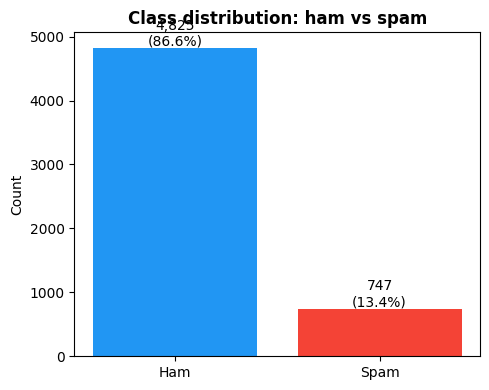

In [5]:
# Write your code here
spam_count = raw['spam'].sum()
ham_count  = (raw['spam'] == 0).sum()
spam_rate  = raw['spam'].mean()

print('Class distribution:')
print(f'  Ham  (0): {ham_count:,}  ({1-spam_rate:.1%})')
print(f'  Spam (1): {spam_count:,}  ({spam_rate:.1%})')
print()

# Prove the accuracy trap with a dummy model
y_all   = raw['spam'].values
y_dummy = np.zeros(len(y_all), dtype=int)
print(f'Dummy model (always predict ham):')
print(f'  Accuracy  = {accuracy_score(y_all, y_dummy):.1%}  <-- misleadingly high')
print(f'  Recall    = {recall_score(y_all, y_dummy, zero_division=0):.1%}  <-- catches zero spam')
print(f'  F1-Score  = {f1_score(y_all, y_dummy, zero_division=0):.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#2196F3', '#F44336'])
ax.set_ylabel('Count')
ax.set_title('Class distribution: ham vs spam', fontweight='bold')
for i, v in enumerate([ham_count, spam_count]):
    ax.text(i, v + 30, f'{v:,}\n({v/len(raw):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### Step 2C — Read the raw text

**Hint:** Print 5 spam examples and 5 ham examples.
Limit each message to 130 characters using string slicing.


In [6]:
print('=== SPAM examples ===')
for i, msg in enumerate(raw[raw['spam']==1]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()

print('=== HAM examples ===')
for i, msg in enumerate(raw[raw['spam']==0]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()


=== SPAM examples ===
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's 

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s

3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code 

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Updat

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 

=== HAM examples ===
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my b

### Step 2D — Message length analysis

**Hint:** Add a column `msg_length = message.str.len()`.
Print average length for spam and ham.
Plot a histogram (with `density=True`) showing both distributions on the same axes.


Average message length:
  Ham  : 71 characters
  Spam : 139 characters


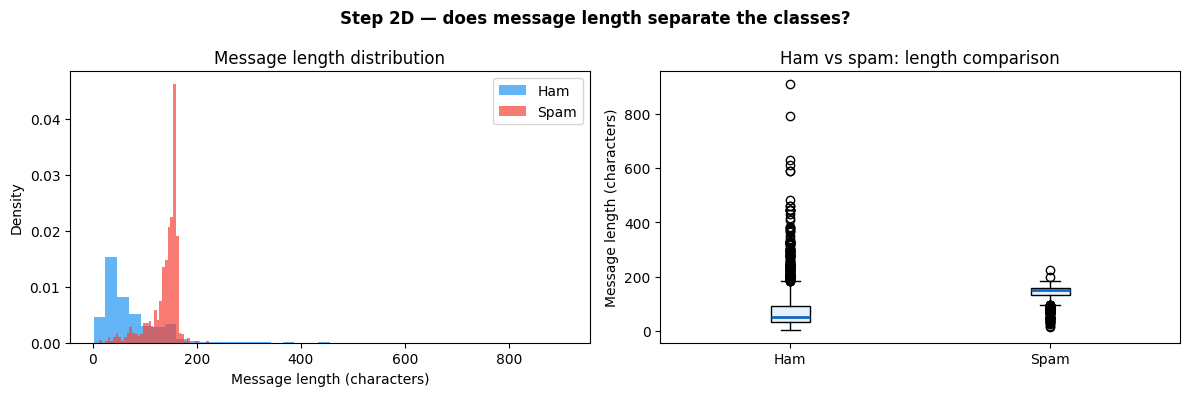

In [7]:
raw['msg_length'] = raw['message'].str.len()

print('Average message length:')
print(f'  Ham  : {raw[raw["spam"]==0]["msg_length"].mean():.0f} characters')
print(f'  Spam : {raw[raw["spam"]==1]["msg_length"].mean():.0f} characters')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw['spam']==0]['msg_length'], bins=40, alpha=0.7,
             color='#2196F3', label='Ham', density=True)
axes[0].hist(raw[raw['spam']==1]['msg_length'], bins=40, alpha=0.7,
             color='#F44336', label='Spam', density=True)
axes[0].set_xlabel('Message length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Message length distribution')
axes[0].legend()

axes[1].boxplot(
    [raw[raw['spam']==0]['msg_length'], raw[raw['spam']==1]['msg_length']],
    labels=['Ham', 'Spam'], patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)
axes[1].set_ylabel('Message length (characters)')
axes[1].set_title('Ham vs spam: length comparison')
plt.suptitle('Step 2D — does message length separate the classes?', fontweight='bold')
plt.tight_layout()
plt.show()


---

---
## Step 3 — Feature Engineering

Raw text cannot go directly into a classifier.
Convert it into **binary features** (0 or 1) — the same format as the Hands-On Lab.

### Step 3A — Pre-built starter features
This cell is given to you. Run it and study the patterns before adding your own.


In [8]:
# This cell is provided — do not modify it
def build_features(df):
    d = df.copy()
    msg = d['message'].str.lower()

    d['has_phone'] = msg.str.contains(
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b|call.*\d{4,}|\b0\d{9,}\b',
        regex=True).astype(int)

    d['has_money'] = msg.str.contains(
        r'\b(free|win|winner|prize|cash|\$|claim|reward|won)\b',
        regex=True).astype(int)

    d['has_urgency'] = msg.str.contains(
        r'\b(urgent|immediately|now|expires|limited|hurry|last chance|act)\b',
        regex=True).astype(int)

    d['is_long'] = (d['message'].str.len() > 130).astype(int)
    return d

df = build_features(raw)
starter = ['has_phone', 'has_money', 'has_urgency', 'is_long']
print('Starter features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in starter:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


Starter features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.


In [9]:
# Write your code here

def build_features_v2(df):
    d = build_features(df)   # keeps all 4 starter features
    msg = d['message'].str.lower()

    # --- Feature 5: Contains ALL CAPS words ([A-Z]{3,}) ---
    d['has_all_caps'] = msg.str.contains(r'[A-Z]{3,}', regex=True).astype(int)

    # --- Feature 6: Contains 'txt', 'text', or 'reply' (call-to-action) ---
    d['has_call_to_action'] = msg.str.contains(r'\b(txt|text|reply)\b', regex=True).astype(int)

    # --- Feature 7: Contains 'guaranteed', 'selected', or 'congratulations' ---
    d['has_spam_keywords'] = msg.str.contains(r'\b(guaranteed|selected|congratulations)\b', regex=True).astype(int)

    return d

df = build_features_v2(raw)

# Collect all feature column names — DO NOT delete this line
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

# Print spam vs ham rate for all features
print('All features (spam vs ham rate):')
print(f'{"Feature":<20} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 48)
for feat in feature_cols:
    sp = df[df['spam']==1][feat].mean()
    ha = df[df['spam']==0][feat].mean()
    print(f'{feat:<20} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')

All features (spam vs ham rate):
Feature                Spam%    Ham%     Gap
------------------------------------------------
has_phone              55.2%    0.1%  +55.1%
has_money              52.3%    2.0%  +50.3%
has_urgency            34.9%    6.4%  +28.5%
is_long                76.8%   14.2%  +62.7%
has_all_caps            0.0%    0.0%   +0.0%
has_call_to_action     40.7%    2.5%  +38.2%
has_spam_keywords      11.1%    0.1%  +11.0%


### Step 3C — Visualize feature gaps

**Hint:** Create one bar chart per feature (use `plt.subplots(1, n_features, ...)`).
Each bar chart shows two bars: spam rate (red) and ham rate (blue).
This is the same chart style used in the Hands-On Lab Step 0.


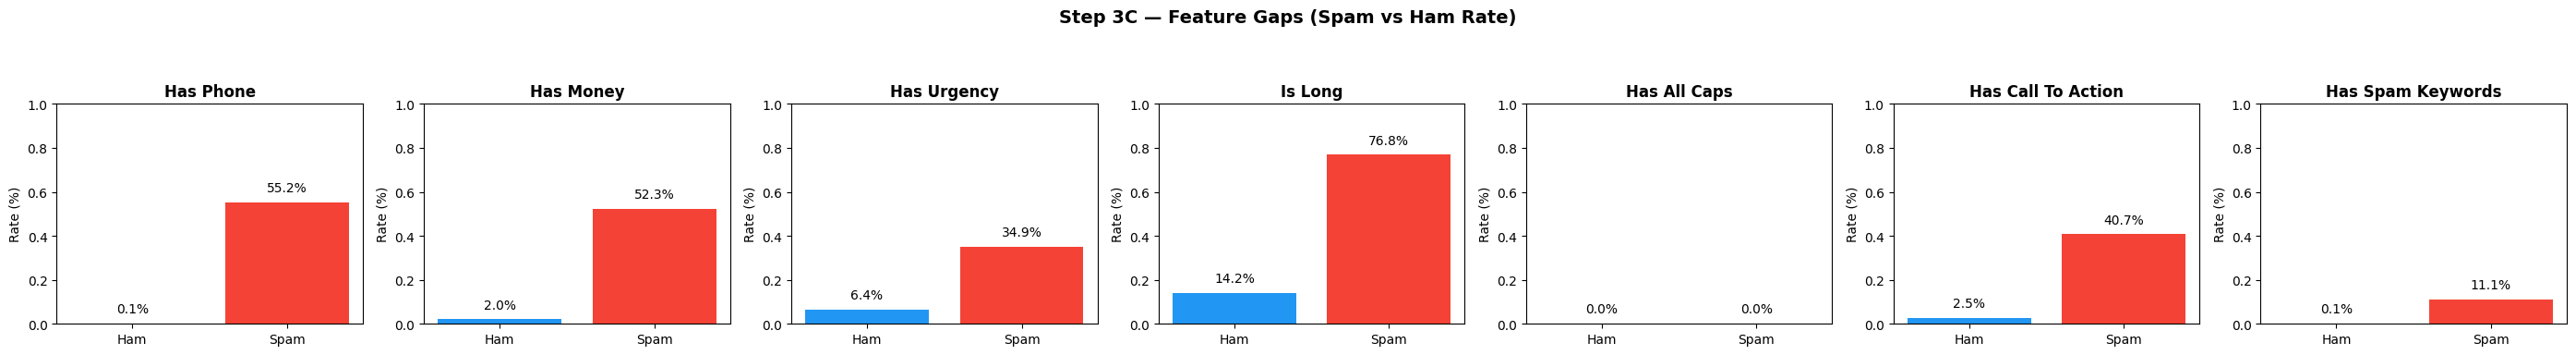

In [10]:
n_features = len(feature_cols)
fig, axes = plt.subplots(1, n_features, figsize=(4 * n_features, 4))

# Ensure axes is an array even if n_features is 1
if n_features == 1:
    axes = [axes]

for i, feat in enumerate(feature_cols):
    spam_rate = df[df['spam']==1][feat].mean()
    ham_rate = df[df['spam']==0][feat].mean()

    ax = axes[i]
    ax.bar(['Ham', 'Spam'], [ham_rate, spam_rate], color=['#2196F3', '#F44336'])
    ax.set_title(f'{feat.replace("_", " ").title()}', fontweight='bold')
    ax.set_ylabel('Rate (%)')
    ax.set_ylim(0, 1) # Rates are between 0 and 1
    for j, val in enumerate([ham_rate, spam_rate]):
        ax.text(j, val + 0.05, f'{val:.1%}', ha='center', fontsize=10)

plt.suptitle('Step 3C — Feature Gaps (Spam vs Ham Rate)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.9]) # Adjust layout to make space for suptitle
plt.show()

### Q3 — Feature Engineering *(20 points)*

**Q3a.** Describe the two features you added.
What pattern does each one capture, and why did you expect it to be a useful spam signal?

*Feature 1 — name and explanation:*
> ... Has All Caps. This feature surprisingly caught nothing in spam or ham so it is not a useful spam signal

*Feature 2 — name and explanation:*
> ... Has Call to Action. This feature works relatively well with a spam rate of 40.7% and 2.5% ham.   

**Q3b.** Which feature has the largest gap between spam and ham?
Why does a large gap matter when a Decision Tree selects its root node?
Connect your answer to the concept of **Information Gain** from Lecture 8.

*Your answer:*
> ... The Feature "Is Long" has the largest gap between spam and ham with a spam rate of 76.8% and ham of 14.2% so a gap of 62.6%. a large gap like this matters for a root node because its most effective at at splitting the data into subsets.

**Q3c.** Look at the spam examples from Step 2C.
Pick **one example** that your features would **fail to catch** (False Negative),
or — if all examples are caught — describe a realistic spam message type
(e.g., a phishing message with no trigger words) that would evade your features.
State which specific feature(s) fail and explain why.

*Your answer:*
> ... #Im gonna go through every feature so this will be long.

Example message: "FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s"
This message would likely be a False Negative with our current set of features:

- has_phone: This message does not contain a phone number in the format our regex expects.
- has_money: While it starts with "FreeMsg", our current regex for has_money does not specifically look for "FreeMsg". It focuses on terms like 'free', 'win', 'prize', 'cash', etc., which are not explicitly present here.
- has_urgency: There are no explicit urgency keywords like 'urgent', 'now', 'expires'.
is_long: The message is 114 characters long, which is not greater than 130, so this feature would be 0.
- has_all_caps: This feature currently always evaluates to 0 because the message is lowercased before the regex is applied (as noted in earlier analysis). Even if fixed, 'XxX' is the only potential candidate and it's mixed case.
- has_call_to_action: No 'txt', 'text', or 'reply' words are present.
- has_spam_keywords: No 'guaranteed', 'selected', or 'congratulations' keywords are found.


---
## Step 4 — Split the Data

### Step 4A — Train/Test split

**Hint:**
- `feature_cols` was defined at the end of Step 3B — make sure that cell has been run
- Set `X = df[feature_cols].values` and `y = df['spam'].values`
- Use `train_test_split` with `test_size=0.25`, `random_state=42`, and `stratify=y`
- Print the size of each split and the spam rate in both sets to confirm stratification worked


In [11]:
X = df[feature_cols].values
y = df['spam'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_test shape:  {y_test.shape}')
print('\nSpam rates:')
print(f'  Train: {y_train.mean():.1%}')
print(f'  Test:  {y_test.mean():.1%}')

X_train shape: (4179, 7)
y_train shape: (4179,)
X_test shape:  (1393, 7)
y_test shape:  (1393,)

Spam rates:
  Train: 13.4%
  Test:  13.4%


### Q4 — Data Split *(10 points)*

**Q4a. (5 points)** Why do we pass `stratify=y`?
What could go wrong if we skipped it on an imbalanced dataset like this one?

*Your answer:*
> ... We pass stratify=y to ensure that the proportion of classes in the training and testing sets is the same as in the original dataset. This makes sure that the results arent misleading due the the random split leaving little to no spam messages in one half.

**Q4b. (5 points)** We use a 75/25 train/test split.
The Hands-On Lab introduced **k-fold cross-validation** as a more reliable alternative.
Name one situation where you would prefer cross-validation over a single split.

*Your answer:*
> ... Cross-validation is useful for small datasets where a single split test may not sufice.Cross-validation uses all data for both training and validation over multiple folds, providing a more robust and less biased estimate of how the model will generalize to unseen data.


---
## Step 5 — Train the Models （Each code 5 pts）

### Step 5A — Decision Tree

**Hint:**
- Use `DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')`
- Fit on the training set
- Print the number of leaves with `.get_n_leaves()`
- Visualize the tree with `plot_tree(..., feature_names=..., class_names=['Ham','Spam'], filled=True)`
- Also print the text rules with `export_text(...)`


Number of leaves: 14


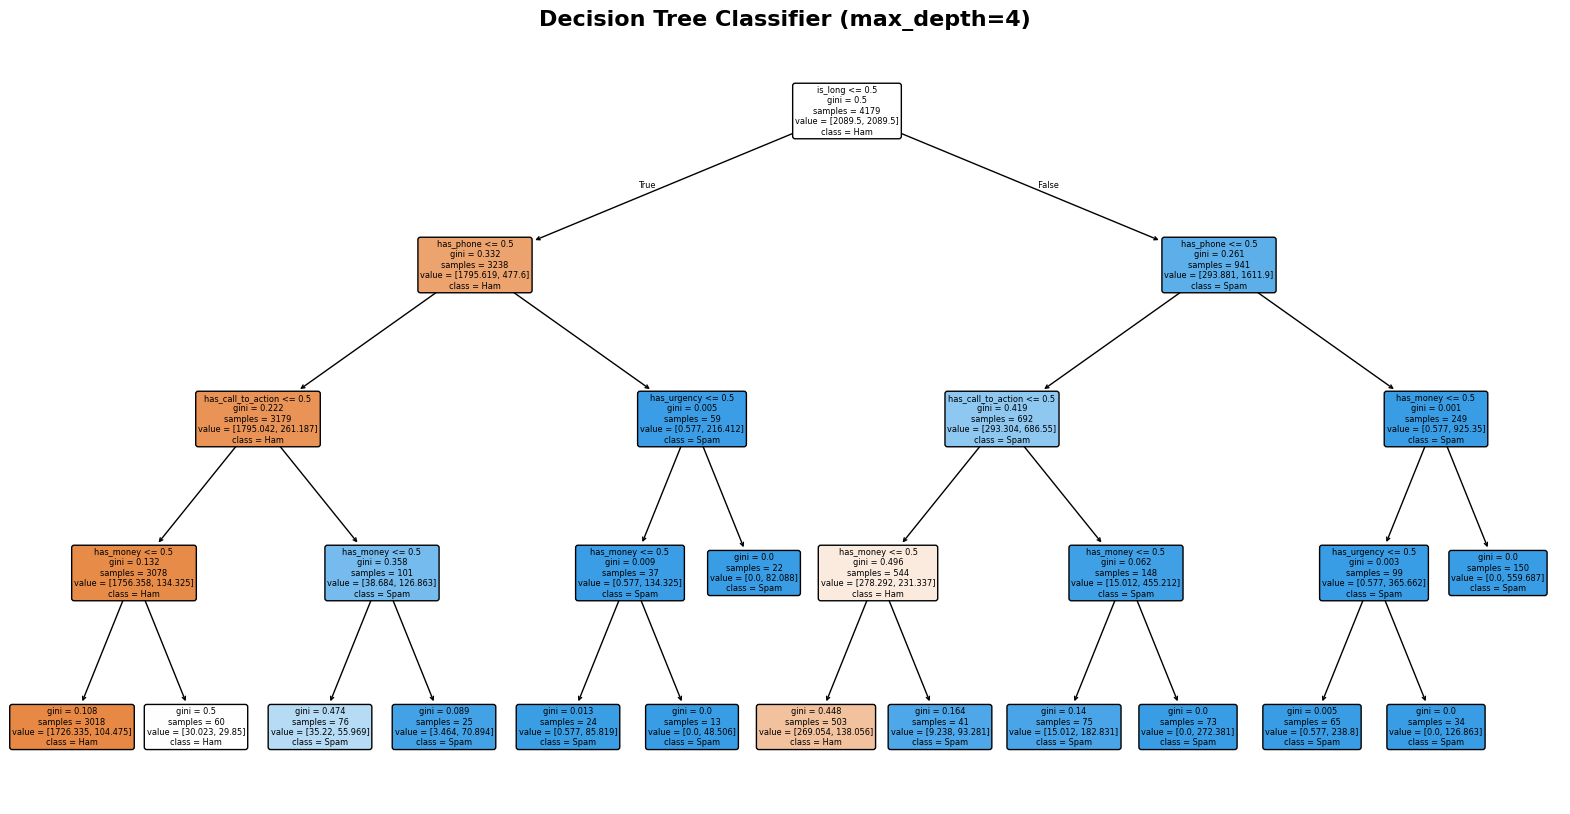


Decision Tree Text Rules:
|--- is_long <= 0.50
|   |--- has_phone <= 0.50
|   |   |--- has_call_to_action <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 0
|   |   |--- has_call_to_action >  0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |--- has_phone >  0.50
|   |   |--- has_urgency <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_urgency >  0.50
|   |   |   |--- class: 1
|--- is_long >  0.50
|   |--- has_phone <= 0.50
|   |   |--- has_call_to_action <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_call_to_action >  0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |

In [12]:
dt_classifier = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
dt_classifier.fit(X_train, y_train)

print(f'Number of leaves: {dt_classifier.get_n_leaves()}')

plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, feature_names=feature_cols,
          class_names=['Ham', 'Spam'], filled=True, rounded=True)
plt.title('Decision Tree Classifier (max_depth=4)', fontsize=16, fontweight='bold')
plt.show()

print('\nDecision Tree Text Rules:')
print(export_text(dt_classifier, feature_names=feature_cols))

### Step 5B — Feature Importance

**Hint:**
- Get `.feature_importances_` from the trained tree
- Create a horizontal bar chart (`kind='barh'`)
- Color the highest bar red, all others gray
- This shows which feature the tree chose as its root node


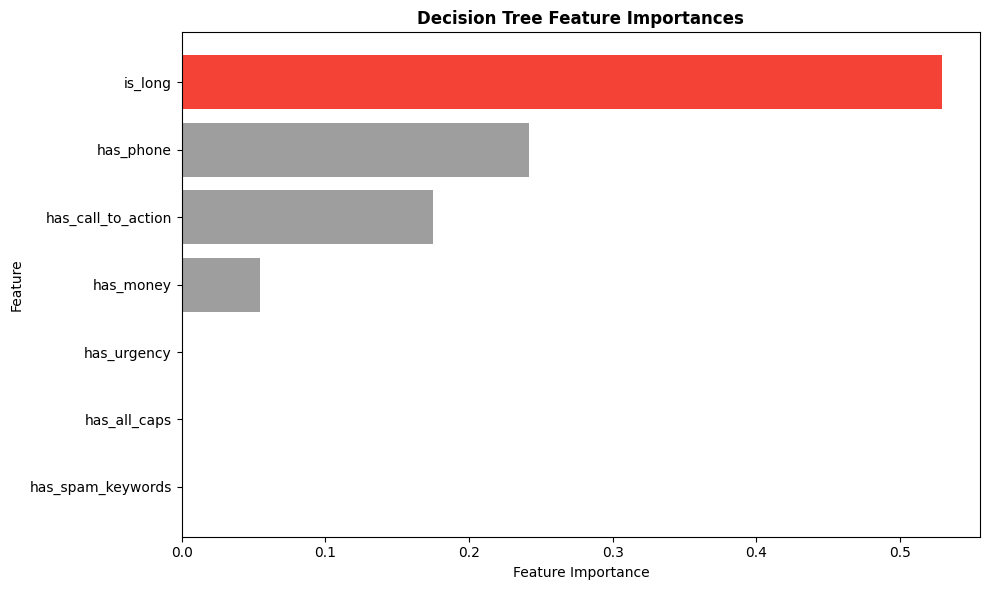

In [14]:
importances = dt_classifier.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#F44336' if imp == feature_importance_df['importance'].max() else '#9E9E9E'
          for imp in feature_importance_df['importance']]

plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color=colors)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Decision Tree Feature Importances', fontweight='bold')
plt.gca().invert_yaxis() # Highest importance at the top
plt.tight_layout()
plt.show()


### Step 5C — Effect of Tree Depth

**Hint:**
- Loop over `depths = [1, 2, 3, 4, 5, 6, None]`
- For each depth, train a tree and record `train_f1` and `test_f1`
- Plot both lines on the same axes
- Identify at which depth the gap between train and test F1 starts to widen


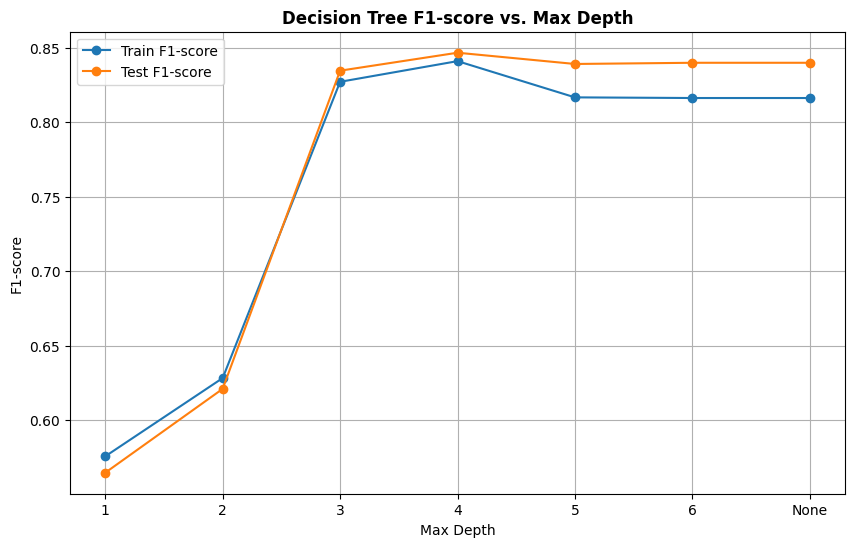

The gap between train and test F1-score does not show a clear widening trend in this range.


In [16]:
depths = [1, 2, 3, 4, 5, 6, None]
train_f1_scores = []
test_f1_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42, class_weight='balanced')
    dt.fit(X_train, y_train)

    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)

    train_f1_scores.append(f1_score(y_train, y_train_pred, zero_division=0))
    test_f1_scores.append(f1_score(y_test, y_test_pred, zero_division=0))

plt.figure(figsize=(10, 6))
plt.plot([str(d) for d in depths], train_f1_scores, marker='o', label='Train F1-score')
plt.plot([str(d) for d in depths], test_f1_scores, marker='o', label='Test F1-score')
plt.title('Decision Tree F1-score vs. Max Depth', fontweight='bold')
plt.xlabel('Max Depth')
plt.ylabel('F1-score')
plt.legend()
plt.grid(True)
plt.show()

# Identify depth where gap starts to widen
depth_labels = [str(d) if d is not None else 'None' for d in depths]
for i in range(1, len(depths)):
    if test_f1_scores[i] < test_f1_scores[i-1] and train_f1_scores[i] > train_f1_scores[i-1]:
        print(f'The gap between train and test F1-score starts to widen around max_depth={depth_labels[i]}')
        break
else:
    print('The gap between train and test F1-score does not show a clear widening trend in this range.')

### Step 5D — Naive Bayes

**Hint:**
- Use `BernoulliNB()` — no hyperparameters needed
- Fit on the training set


In [17]:
nb_classifier = BernoulliNB()
nb_classifier.fit(X_train, y_train)

BernoulliNB()

---
## Step 6 — Evaluate *(Each code block 4 points)*

### Step 6A — Confusion Matrices

**Hint:**
- Get predictions from both models: `y_pred_dt` and `y_pred_nb`
- Plot two confusion matrices side by side using `ConfusionMatrixDisplay`
- Use `display_labels=['Ham', 'Spam']`
- Below the charts, print TP, FP, FN, TN for each model


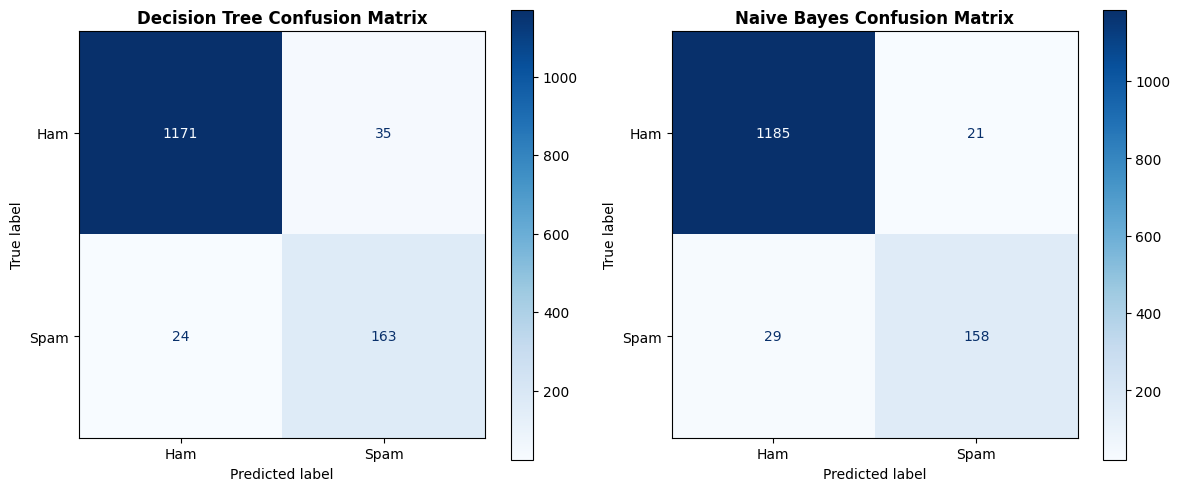

Decision Tree Metrics:
  True Positives (TP): 163
  False Positives (FP): 35
  False Negatives (FN): 24
  True Negatives (TN): 1171

Naive Bayes Metrics:
  True Positives (TP): 158
  False Positives (FP): 21
  False Negatives (FN): 29
  True Negatives (TN): 1185


In [18]:
y_pred_dt = dt_classifier.predict(X_test)
y_pred_nb = nb_classifier.predict(X_test)

# Calculate confusion matrices
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_dt, display_labels=['Ham', 'Spam']).plot(cmap='Blues', ax=axes[0])
axes[0].set_title('Decision Tree Confusion Matrix', fontweight='bold')

ConfusionMatrixDisplay(cm_nb, display_labels=['Ham', 'Spam']).plot(cmap='Blues', ax=axes[1])
axes[1].set_title('Naive Bayes Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

# Print TP, FP, FN, TN for Decision Tree
TN_dt, FP_dt, FN_dt, TP_dt = cm_dt.ravel()
print('Decision Tree Metrics:')
print(f'  True Positives (TP): {TP_dt}')
print(f'  False Positives (FP): {FP_dt}')
print(f'  False Negatives (FN): {FN_dt}')
print(f'  True Negatives (TN): {TN_dt}')

print('\nNaive Bayes Metrics:')
TN_nb, FP_nb, FN_nb, TP_nb = cm_nb.ravel()
print(f'  True Positives (TP): {TP_nb}')
print(f'  False Positives (FP): {FP_nb}')
print(f'  False Negatives (FN): {FN_nb}')
print(f'  True Negatives (TN): {TN_nb}')

### Step 6B — Metrics Comparison

**Hint:**
- Build a DataFrame with columns: Model, Accuracy, Precision, Recall, F1-Score
- One row per model
- Also create a grouped bar chart comparing all four metrics side by side


Model Performance Comparison:
           Model  Accuracy  Precision  Recall  F1-Score
0  Decision Tree     0.958      0.823   0.872     0.847
1    Naive Bayes     0.964      0.883   0.845     0.863


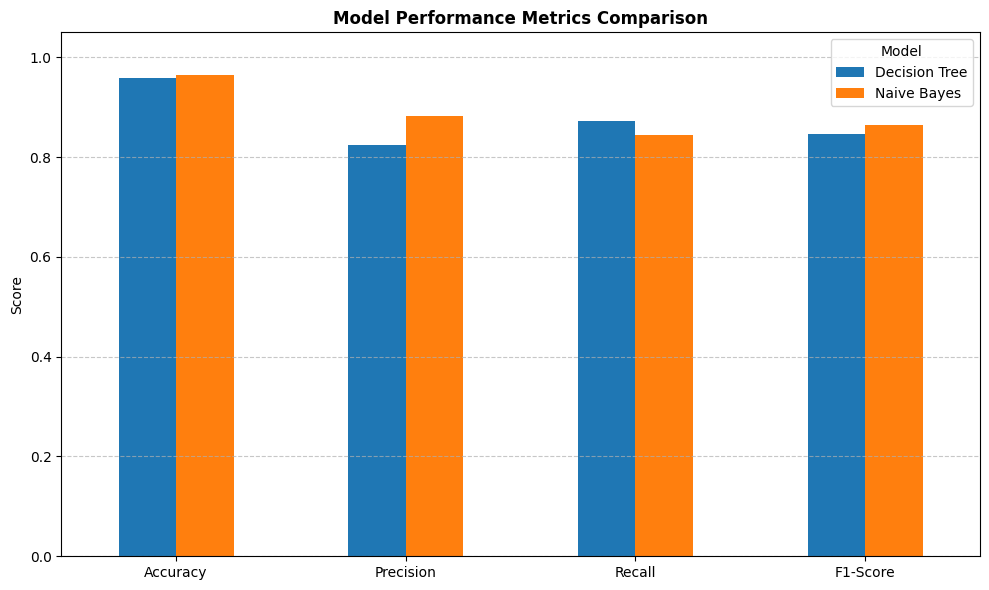

In [19]:
# Calculate metrics for Decision Tree
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, zero_division=0)
recall_dt = recall_score(y_test, y_pred_dt, zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, zero_division=0)

# Calculate metrics for Naive Bayes
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, zero_division=0)
recall_nb = recall_score(y_test, y_pred_nb, zero_division=0)
f1_nb = f1_score(y_test, y_pred_nb, zero_division=0)

# Create a DataFrame for comparison
metrics_data = {
    'Model': ['Decision Tree', 'Naive Bayes'],
    'Accuracy': [accuracy_dt, accuracy_nb],
    'Precision': [precision_dt, precision_nb],
    'Recall': [recall_dt, recall_nb],
    'F1-Score': [f1_dt, f1_nb]
}
metrics_df = pd.DataFrame(metrics_data)
print('Model Performance Comparison:')
print(metrics_df.round(3))

# Plotting the comparison
metrics_df.set_index('Model').T.plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('Model Performance Metrics Comparison', fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.05) # Metrics are between 0 and 1
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Step 6C — Cross-Validation

**Hint:**
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- Run `cross_val_score` with `scoring='f1'` for both models
- Print the average F1 across 5 folds for each model


In [21]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation for Decision Tree
f1_scores_dt_cv = cross_val_score(dt_classifier, X, y, cv=kf, scoring='f1')
print(f'Decision Tree (CV F1-score): {f1_scores_dt_cv.mean():.3f} (+/- {f1_scores_dt_cv.std():.3f})')

# Cross-validation for Naive Bayes
f1_scores_nb_cv = cross_val_score(nb_classifier, X, y, cv=kf, scoring='f1')
print(f'Naive Bayes (CV F1-score): {f1_scores_nb_cv.mean():.3f} (+/- {f1_scores_nb_cv.std():.3f})')

Decision Tree (CV F1-score): 0.822 (+/- 0.034)
Naive Bayes (CV F1-score): 0.870 (+/- 0.015)


### Q6 — Evaluation & Analysis *(25 points)*

> **Points breakdown:**
> - Step 6A code (runs correctly): 4 pts
> - Step 6B code (runs correctly): 4 pts
> - Step 6C code (runs correctly): 4 pts
> - Q6a written: 3 pts
> - Q6b written: 3 pts
> - Q6c written: 4 pts
> - Q6d written: 3 pts
> - **Total: 25 pts**

---

**Q6a. Read the confusion matrices (Step 6A) — *(3 points)***

For each model, state:
- How many spam messages were correctly caught (True Positives)?
- How many spam messages slipped through (False Negatives)?
- How many legitimate messages were wrongly blocked (False Positives)?

*Decision Tree:*
> - 163
 - 24
 - 35

*Naive Bayes:*
> - 158
 - 29
 - 21

**Q6b. Apply your metric from Q1b — *(3 points)***

Which model wins on the metric you chose in Step 1?
By how much? Does the cross-validation result (Step 6C) confirm this?

*Your answer:*
> the model that wins based on F1 score is Naive Bayes by 0.016. and it does hold up after cross examination.

**Q6c. Recommendation memo — *(4 points)***

Imagine you are presenting to a product manager at a mobile carrier.
Write 4–5 sentences that:
1. State which model you recommend
2. Justify the choice with one specific number from your results
3. Acknowledge one weakness of your recommended model
4. Propose one concrete improvement

*Your memo:*
> I recommend the Naive Bayes model for our SMS spam filter. It achieved a cross-validated F1-score of 0.870, outperforming the Decision Tree. This choice is particularly strong because it produced fewer False Positives (21) compared to the Decision Tree (35), which is critical for avoiding the blocking of legitimate messages. However, its weakness is a slightly higher False Negative rate, meaning a few more spam messages might still reach users. A concrete improvement would be to enhance our text preprocessing pipeline, perhaps by incorporating more sophisticated natural language processing techniques like TF-IDF or word embeddings to capture more nuanced spam patterns.

**Q6d. Generalization — *(3 points)***

The SMS Spam Collection was collected in the early 2010s.
Modern spam often uses professional language and legitimate-looking URLs.
Identify **two features you built** that would likely fail on modern spam, and explain why.

*Your answer:*
> Two features that would likely fail on modern spam are `has_spam_keywords` and `has_money`.

`has_spam_keywords` (detecting words like 'guaranteed', 'selected', 'congratulations') would likely fail because modern spam, especially phishing, aims to appear legitimate and now avoid spam signaling language. Instead, it might mimic official communications or use social engineering to trick users without these explicit keywords.

`has_money` (detecting words like 'free', 'win', 'prize', 'cash', '$') could also be less effective. While some spam still targets money, sophisticated scams often focus on tricking users into revealing personal information or clicking malicious links, rather than explicitly offering monetary prizes or deals, thus avoiding these keywords to appear less suspicious.